### Video processing

In [5]:
from ultralytics import YOLO
import cv2
import time


def process_video_with_tracking(model, input_video, show_video=True, save_video=False):
    # Open the input video file
    input_video_path = f'input_videos/{input_video}.mp4' if input_video != 0 else 0
    cap = cv2.VideoCapture(input_video_path)

    if not cap.isOpened():
        raise Exception("Error: Could not open video file.")

    # Get input video frame rate and dimensions
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Define the output video writer
    if save_video:
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        output_path = f'output_videos/{input_video}_result.mp4'
        out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    colors = {
        'CocaCola': (0, 0, 255),  # Red
        'Pepsi': (255, 0, 0)     # Blue
    }

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        start_time = time.time()

        # Track objects in the frame
        results = model.track(source=frame, persist=True, conf=0.6, verbose=False, tracker="bytetrack.yaml")[0]

        # Draw bounding boxes and labels on the frame
        for box in results.boxes:
            cls_id = int(box.cls[0])
            label = model.names[cls_id]
            conf = box.conf[0]
            track_id = int(box.id[0]) if box.id is not None else None
                
            if track_id is None:
                continue
                
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            color = colors.get(label[:-4], (255, 255, 255)) # White by default
            label_text = f"{label[:-4]}: {conf:.2f}conf"
            
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(
                frame,
                label_text,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                2
                )


        # FPS
        end_time = time.time()
        fps = 1 / (end_time - start_time + 1e-6)
        fps_text = f'FPS: {fps:.2f}'
        cv2.putText(frame, fps_text, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, 
                    (0, 255, 255), 2)
        
        if save_video:
            out.write(frame)

        if show_video:
            cv2.imshow('Object Detection', frame)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    # Release the input video capture and output video writer
    cap.release()
    if save_video:
        out.release()

    # Close all OpenCV windows
    cv2.destroyAllWindows()


# Example usage:
model = YOLO('ColaPepsiNet.pt')
model.fuse()
results = process_video_with_tracking(model, 
                                      input_video = 'video_1',
                                      show_video=True,
                                      save_video=False
                                      )

Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs


### Image processing

Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
Pepsi: 96%
CocaCola: 96%
CocaCola: 95%
CocaCola: 95%
CocaCola: 95%
Pepsi: 92%
Pepsi: 90%


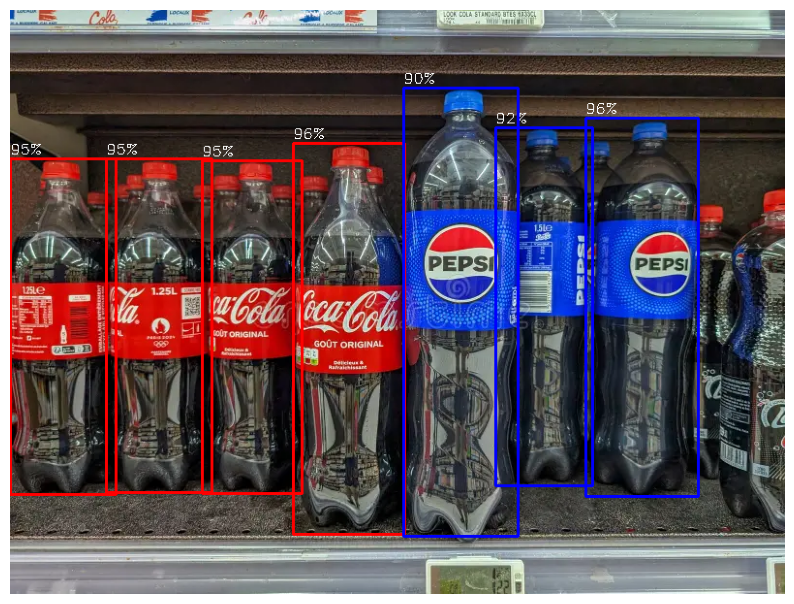

In [6]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt


def process_photo(model, image_path):
    img = cv2.imread(image_path)
    results = model.track(source=img, persist=True, conf=0.6, verbose=False)[0]

    colors = {
        'CocaCola': (0, 0, 255),  # Red
        'Pepsi': (255, 0, 0)     # Blue
    }

    for box in results.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]
        conf = box.conf[0]
        track_id = int(box.id[0]) if box.id is not None else None
            
        if track_id is None:
            continue
            
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = colors.get(label[:-4], (255, 255, 255)) # White by default
        label_text = f"{label[:-4]}: {int(conf*100)}%"
        print(label_text)
        
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            img,
            f"{int(conf*100)}%",
            (x1, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1
        )
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

# # Example usage:
model = YOLO('ColaPepsiNet.pt')
model.fuse()
process_photo(model, image_path = "image1.webp")